# Content-Based Filtering mit TF-IDF
## Produktbasiertes Empfehlungssystem – gebana AG

**Autor:** Emircan Akyürek  
**Kontext:** gebana AG – Schweizer E-Commerce für fair gehandelte Lebensmittel  
**Ansatz:** Content-Based Filtering auf Basis von TF-IDF und Kosinus-Ähnlichkeit

---

**Ablauf:**
1. Datenladen und Exploration
2. Textvorverarbeitung (Tokenisierung, Stopwörter, Stemming)
3. TF-IDF-Berechnung
4. Vektordarstellung und Visualisierungen
5. Kosinus-Ähnlichkeit
6. Empfehlungsfunktion und Anwendungsbeispiele

---
## 0. Imports und Konfiguration

In [1]:
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 100
print('Alle Bibliotheken geladen.')

Alle Bibliotheken geladen.


In [2]:
# ============================================================
# KONFIGURATION
# ============================================================
CSV_DATEI     = 'Produktbeschreibungen.csv'
CSV_TRENNER   = ';'
CSV_ENCODING  = 'utf-8-sig'

USE_STOPWORDS = False   # Stopwörter entfernen?
USE_STEMMING  = False   # Stemming anwenden?
TOP_N           = 6      # Anzahl Empfehlungen
MIN_TEXT_LAENGE = 50    # Mindestlaenge des kombinierten Textes (Zeichen)

print(f'Stopwörter: {"aktiv" if USE_STOPWORDS else "deaktiviert"}')
print(f'Stemming:   {"aktiv" if USE_STEMMING else "deaktiviert"}')
print(f'Top-N:          {TOP_N}')
print(f'Min. Textlänge: {MIN_TEXT_LAENGE} Zeichen')

Stopwörter: deaktiviert
Stemming:   deaktiviert
Top-N:          6
Min. Textlänge: 50 Zeichen


---
## 1. Datenbasis

Die Produktdaten stammen aus dem PIM-System der gebana AG. Jede Zeile entspricht einem Produkt. Für das Empfehlungssystem werden folgende Felder zusammengeführt:

| Quellspalte | Bedeutung |
|---|---|
| Artikelname | Produktname |
| Produkttext Shop | Freitextbeschreibung |
| Anbau | Anbauinformationen |
| Nachhaltigkeit | Nachhaltigkeitsinfos |
| Verwendung | Verwendungshinweise |

In [3]:
df_roh = pd.read_csv(CSV_DATEI, sep=CSV_TRENNER, encoding=CSV_ENCODING, dtype=str)

print(f'Zeilen: {len(df_roh)}')
print(f'Spalten: {len(df_roh.columns)}')
df_roh.head(3)

Zeilen: 1705
Spalten: 14


,TYPE,NAVIGATIONPATH,EXTERNALKEY,Artikelname (KOM --> Übersetzung),Produkttext Shop (KOM --> Übersetzung),Anbau - übersetzen (KOM),Einkauf & Logistik - übersetzen (KOM),Produzierende - übersetzen (KOM),Verarbeitung - übersetzen (KOM),Nachhaltigkeit & Transparenz (KOM),Verwendung & Zubereitung (KOM --> Übersetzung),Aufbewahrung & Haltbarkeit (KOM --> Übersetzung),Herkunft (KOM),Category ID Shopware (Kategorien)
0,Artikel,Direktversand > Archiv > Archiv-Trockenprodukt...,1017568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Artikel,Direktversand > Archiv > Archiv-A2M > ZZ-Archi...,1020633,A2M 1 kg Barunüsse,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Artikel,Direktversand > Archiv > Archiv-A2M > ZZ-Archi...,1020719,A2M 1 kg Paranüsse gewürzt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
SPALTEN = {
    'Artikelname (KOM --> Übersetzung)':            'name',
    'Produkttext Shop (KOM --> Übersetzung)':        'beschreibung',
    'NAVIGATIONPATH':                                'navigationpfad',
    'Anbau - übersetzen (KOM)':                      'anbau',
    'Nachhaltigkeit & Transparenz (KOM)':            'nachhaltigkeit',
    'Verwendung & Zubereitung (KOM --> Übersetzung)':'verwendung',
    'EXTERNALKEY':                                   'artikel_id',
    'TYPE':                                          'typ'
}

df = df_roh.rename(columns=SPALTEN).copy()

# Nur Artikel behalten (keine Kategorieknoten)
df = df[df['typ'] == 'Artikel'].copy()

# Nur Produkte mit Namen
df = df[df['name'].notna() & (df['name'].str.strip() != '')].copy()
df = df.reset_index(drop=True)

print(f'Artikel nach Filterung: {len(df)}')
df[['artikel_id', 'name']].head(6)

Artikel nach Filterung: 1193


,artikel_id,name
0,1020633,A2M 1 kg Barunüsse
1,1020719,A2M 1 kg Paranüsse gewürzt
2,1020720,A2M 1 kg Paranüsse natur
3,1017400,10 x Einkaufsgutschein gebana CHF 30.-
4,1021499,12x Schokolade aus Togo - A2M
5,1021033,15 Tafeln Schokolade ChocoSamona - A2M


### 1.1 Datenexploration

In [5]:
felder = ['name', 'beschreibung', 'anbau', 'nachhaltigkeit', 'verwendung']

fuellrate = pd.DataFrame({
    'Feld':        felder,
    'Befüllt':     [df[f].notna().sum() for f in felder],
    'Leer':        [df[f].isna().sum()  for f in felder],
    'Füllrate (%)': [round(df[f].notna().mean() * 100, 1) for f in felder]
})

print('Datenvollständigkeit:')
print(fuellrate.to_string(index=False))

Datenvollständigkeit:
          Feld  Befüllt  Leer  Füllrate (%)
          name     1193     0         100.0
  beschreibung      859   334          72.0
         anbau      129  1064          10.8
nachhaltigkeit      143  1050          12.0
    verwendung      120  1073          10.1


### 1.2 Textfelder zusammenführen

In [6]:
def felder_zusammenfuehren(row):
    teile = [
        str(row.get('name', '') or ''),
        str(row.get('beschreibung', '') or ''),
        str(row.get('anbau', '') or ''),
        str(row.get('nachhaltigkeit', '') or ''),
        str(row.get('verwendung', '') or ''),
    ]
    return ' '.join(t for t in teile if t.strip())


df['text_combined'] = df.apply(felder_zusammenfuehren, axis=1)

laengen = df['text_combined'].str.len()
print(f'Durchschnittliche Textlänge: {laengen.mean():.0f} Zeichen')
print(f'Min: {laengen.min()} | Max: {laengen.max()}')
print()
print('Beispiel:')
print(df['text_combined'].iloc[5][:300])

Durchschnittliche Textlänge: 419 Zeichen
Min: 21 | Max: 2167

Beispiel:
15 Tafeln Schokolade ChocoSamona - A2M nan nan nan nan


---
## 2. Textvorverarbeitung

Die Pipeline besteht aus drei Schritten:

| Schritt | Beschreibung | Optional |
|---|---|---|
| **Tokenisierung** | Kleinbuchstaben, Sonderzeichen entfernen, aufteilen | Nein |
| **Stopwort-Entfernung** | Funktionswörter entfernen (und, in, die, ...) | Ja |
| **Stemming** | Wörter auf Wortstamm reduzieren | Ja |

**Wichtig:** Deutsche Umlaute (ä, ö, ü, ß) und ae/oe/ue werden behalten.

### 2.1 Tokenisierung

In [7]:
def tokenize(text):
    """
    Tokenisiert einen Text:
    - Kleinbuchstaben
    - Entfernt Sonderzeichen (behält Umlaute ä, ö, ü und ß)
    - Teilt in einzelne Wörter (Tokens)
    """
    text = str(text).lower()
    text = re.sub(r'[^a-z\u00e4\u00f6\u00fc\u00df\s]', ' ', text)
    tokens = text.split()
    return tokens


beispiel = 'Cashews Nature 1 kg Bio-zertifiziert aus Burkina Faso!'
print(f'Eingabe: {beispiel}')
print(f'Tokens:  {tokenize(beispiel)}')

Eingabe: Cashews Nature 1 kg Bio-zertifiziert aus Burkina Faso!
Tokens:  ['cashews', 'nature', 'kg', 'bio', 'zertifiziert', 'aus', 'burkina', 'faso']


### 2.2 Stopwort-Entfernung (optional)

In [8]:
STOP_WORDS = set(stopwords.words('german'))

# Eigene Erweiterungen (domänenspezifisch)
STOP_WORDS.update({'ca', 'kg', 'ml', 'gr', 'mindestens', 'haltbar', 'bis', 'nan'})


def remove_stopwords(tokens):
    """Entfernt deutsche Stoppwörter aus einer Token-Liste."""
    return [t for t in tokens if t not in STOP_WORDS]


tokens_bsp = tokenize('Die getrockneten Ananasstücke schmecken süss und leicht säuerlich.')
print(f'Vor:  {tokens_bsp}')
print(f'Nach: {remove_stopwords(tokens_bsp)}')
print(f'\nAnzahl Stoppwörter: {len(STOP_WORDS)}')

Vor:  ['die', 'getrockneten', 'ananasstücke', 'schmecken', 'süss', 'und', 'leicht', 'säuerlich']
Nach: ['getrockneten', 'ananasstücke', 'schmecken', 'süss', 'leicht', 'säuerlich']

Anzahl Stoppwörter: 239


### 2.3 Stemming (optional)

Der SnowballStemmer für Deutsch reduziert Wörter auf ihren Wortstamm,
damit morphologische Varianten als gleichwertig erkannt werden.

Einschränkung: Stemming arbeitet regelbasiert ohne semantische Zusammenhänge.

In [9]:
stemmer = SnowballStemmer('german')


def stem_tokens(tokens):
    """Reduziert Tokens auf ihren deutschen Wortstamm."""
    return [stemmer.stem(t) for t in tokens]


varianten = ['empfehlen', 'Empfehlung', 'empfohlen', 'getrocknet', 'Trocknung', 'trocken']
print(f'{"Original":<20} {"Wortstamm":<20}')
print('-' * 40)
for w in varianten:
    print(f'{w:<20} {stemmer.stem(w.lower()):<20}')

Original             Wortstamm           
----------------------------------------
empfehlen            empfehl             
Empfehlung           empfehl             
empfohlen            empfohl             
getrocknet           getrocknet          
Trocknung            trocknung           
trocken              trock               


### 2.4 Gesamte Vorverarbeitungs-Pipeline

In [10]:
def preprocess(text):
    """
    Vollständige Vorverarbeitungs-Pipeline:
    1. Tokenisierung (immer aktiv)
    2. Stopwort-Entfernung (steuerbar via USE_STOPWORDS)
    3. Stemming (steuerbar via USE_STEMMING)
    """
    tokens = tokenize(text)

    if USE_STOPWORDS:
        tokens = remove_stopwords(tokens)

    if USE_STEMMING:
        tokens = stem_tokens(tokens)

    # Zu kurze Tokens entfernen
    tokens = [t for t in tokens if len(t) >= 2]

    return ' '.join(tokens)


df['text_clean'] = df['text_combined'].apply(preprocess)

leer = (df['text_clean'].str.strip() == '').sum()
print(f'Vorverarbeitung abgeschlossen.')
print(f'  Produkte gesamt:          {len(df)}')
print(f'  Produkte mit leerem Text: {leer}')
print()

# Vorher/Nachher-Beispiel
idx = df[df['text_combined'].str.len() > 200].index[0]
print('Original (Auszug):')
print(df.loc[idx, 'text_combined'][:250])
print('\nVorverarbeitet (Auszug):')
print(df.loc[idx, 'text_clean'][:250])

Vorverarbeitung abgeschlossen.
  Produkte gesamt:          1193
  Produkte mit leerem Text: 0

Original (Auszug):
10 x Einkaufsgutschein gebana CHF 30.- Schenken Sie etwas Sinnvolles und Feines! Mit einem Gutschein für einen Einkauf bei uns können sich die Beschenkten selber etwas aus unserem Sortiment aussuchen. Sie können wählen, ob Sie den Gutschein per Email

Vorverarbeitet (Auszug):
einkaufsgutschein gebana chf schenken sie etwas sinnvolles und feines mit einem gutschein für einen einkauf bei uns können sich die beschenkten selber etwas aus unserem sortiment aussuchen sie können wählen ob sie den gutschein per email selbst erhal


### 2.5 Visualisierung: Effekt der Stopwort-Entfernung

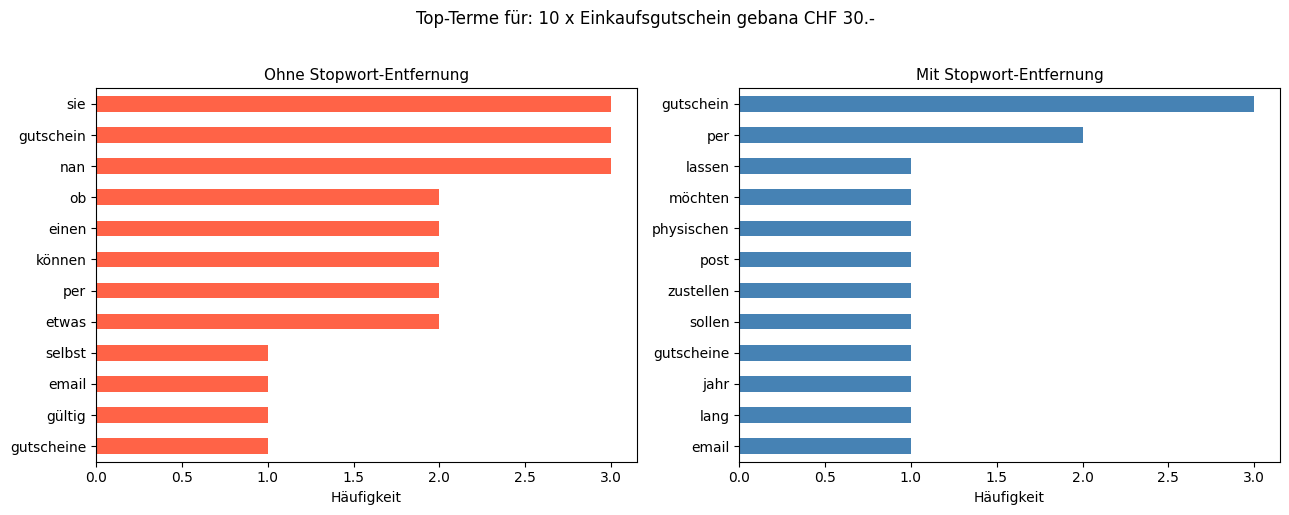

Token-Reduktion: 63 -> 32 (-31 Stoppwörter, 49.2% Reduktion)


In [11]:
idx_bsp = df[df['beschreibung'].notna() & (df['beschreibung'].str.len() > 300)].index[0]
produkt_name_bsp = df.loc[idx_bsp, 'name']
text_bsp = df.loc[idx_bsp, 'text_combined']

tokens_alle  = tokenize(text_bsp)
tokens_gefilt = [t for t in tokens_alle if t not in STOP_WORDS]

freq_alle  = pd.Series(tokens_alle).value_counts().head(12)
freq_gefilt = pd.Series(tokens_gefilt).value_counts().head(12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

freq_alle.sort_values().plot(kind='barh', ax=ax1, color='tomato')
ax1.set_title('Ohne Stopwort-Entfernung', fontsize=11)
ax1.set_xlabel('Häufigkeit')

freq_gefilt.sort_values().plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_title('Mit Stopwort-Entfernung', fontsize=11)
ax2.set_xlabel('Häufigkeit')

fig.suptitle(f'Top-Terme für: {produkt_name_bsp[:40]}', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Token-Reduktion: {len(tokens_alle)} -> {len(tokens_gefilt)} '
      f'(-{len(tokens_alle)-len(tokens_gefilt)} Stoppwörter, '
      f'{(1 - len(tokens_gefilt)/len(tokens_alle))*100:.1f}% Reduktion)')

---
## 3. TF-IDF-Berechnung

TF-IDF (Term Frequency – Inverse Document Frequency) bestimmt die Relevanz eines Begriffs
innerhalb eines Dokuments im Verhältnis zur gesamten Dokumentensammlung.

**TF(i, j)** = Häufigkeit von Term i in Dokument j, normiert durch den häufigsten Term

**IDF(i)** = log( N / n(i) ) mit N = Gesamtanzahl Dokumente, n(i) = Dokumente mit Term i

**TF-IDF(i, j)** = TF(i, j) x IDF(i)

Ein hoher Wert bedeutet: Term kommt häufig in diesem Produkt vor, aber selten im gesamten Katalog.

In [12]:
# Produkte mit zu kurzem kombiniertem Text ausschließen (vgl. 01-Empfehlungen-berechnen.py)
df['text_laenge'] = df['text_combined'].str.len()
n_vor = len(df)
df_model = df[df['text_laenge'] >= MIN_TEXT_LAENGE].copy().reset_index(drop=True)
n_ausgeschlossen = n_vor - len(df_model)
print(f'Produkte gesamt:      {n_vor}')
print(f'Ausgeschlossen (<{MIN_TEXT_LAENGE} Zeichen): {n_ausgeschlossen}')
print(f'Produkte im Modell:   {len(df_model)}')

# TF-IDF-Vektorisierer
vectorizer = TfidfVectorizer(
    analyzer='word',
    token_pattern=r'[a-z\u00e4\u00f6\u00fc\u00df]+',
    min_df=2,        # Term muss in mind. 2 Dokumenten vorkommen
    max_df=0.95,     # Term darf in max. 95% der Dokumente vorkommen
    sublinear_tf=True  # log(1+TF) statt roh TF
)

tfidf_matrix = vectorizer.fit_transform(df_model['text_clean'])
feature_names = vectorizer.get_feature_names_out()

print(f'\nTF-IDF-Matrix:')
print(f'  Zeilen (Produkte): {tfidf_matrix.shape[0]}')
print(f'  Spalten (Terme):   {tfidf_matrix.shape[1]}')
print(f'  Nicht-Null-Eintr.: {tfidf_matrix.nnz}')
sparsity = 1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])
print(f'  Sparsity:          {sparsity:.2%}')

Produkte gesamt:      1193
Ausgeschlossen (<50 Zeichen): 267
Produkte im Modell:   926

TF-IDF-Matrix:
  Zeilen (Produkte): 926
  Spalten (Terme):   3653
  Nicht-Null-Eintr.: 48879
  Sparsity:          98.56%


### 3.1 Berechnungsbeispiel für ein Produkt

In [13]:
# Produkt mit den meisten Nicht-Null-Einträgen wählen
nnz_pro_zeile = np.diff(tfidf_matrix.indptr)
bsp_idx = int(np.argmax(nnz_pro_zeile))
bsp_name = df_model.loc[bsp_idx, 'name']

print(f'Beispielprodukt: {bsp_name}')
print()

# Top-10 Terme nach TF-IDF-Wert
bsp_vektor = tfidf_matrix[bsp_idx]
non_zero_idx = bsp_vektor.nonzero()[1]
tfidf_paare = [(feature_names[i], bsp_vektor[0, i]) for i in non_zero_idx]
tfidf_top = sorted(tfidf_paare, key=lambda x: x[1], reverse=True)[:10]

idf_lookup = dict(zip(feature_names, vectorizer.idf_))

tabelle = []
for term, tfidf_val in tfidf_top:
    tabelle.append({
        'Term':        term,
        'IDF(i)':      round(idf_lookup[term], 4),
        'TF-IDF(i,j)': round(tfidf_val, 4)
    })

df_tabelle = pd.DataFrame(tabelle)
print(df_tabelle.to_string(index=False))

Beispielprodukt: Clementinen Saisonangebot bio 2x8kg EU VORBESTELLUNG

           Term  IDF(i)  TF-IDF(i,j)
    clementinen  5.4341       0.2037
          kerne  4.1184       0.1544
       insekten  6.2225       0.1513
fremdbestäubung  6.2225       0.1513
        solchen  6.2225       0.1513
     clementine  6.0402       0.1469
       kreuzung  5.7525       0.1399
           gibt  4.9987       0.1216
          eines  4.9416       0.1202
            nur  4.3056       0.1047


---
## 4. Vektordarstellung

Jedes Produkt wird als Vektor im hochdimensionalen TF-IDF-Raum repräsentiert.
Die Term-Dokument-Matrix enthält in jeder Zeile den Produktvektor.
Die Matrix ist dünn besetzt (sparse), da die meisten Produkte nur einen kleinen
Teil des Gesamtvokabulars verwenden.

In [14]:
# Term-Dokument-Matrix als DataFrame (Ausschnitt)
N_PROD  = min(10, len(df_model))
N_TERME = 20

mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx = np.argsort(mean_tfidf)[::-1][:N_TERME]
top_terme = feature_names[top_idx]

subset = tfidf_matrix[:N_PROD, :][:, top_idx].toarray()

tfidf_df = pd.DataFrame(
    subset,
    columns=top_terme,
    index=df_model['name'].iloc[:N_PROD]
)

print(f'Term-Dokument-Matrix ({N_PROD} Produkte x {N_TERME} Terme):')
tfidf_df.round(3)

Term-Dokument-Matrix (10 Produkte x 20 Terme):


,und,der,die,in,von,aus,mit,sie,den,bio,im,sind,für,ist,oder,nach,das,auf,sich,bauernfamilien
name,,,,,,,,,,,,,,,,,,,,
10 x Einkaufsgutschein gebana CHF 30.-,0.038,0.000,0.045,0.000,0.000,0.047,0.050,0.117,0.060,0.0,0.00,0.067,0.067,0.000,0.068,0.000,0.000,0.00,0.07,0.0
15 Tafeln Schokolade ChocoSamona - A2M,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,0.0
Paranussaufstrich mit Kakao,0.072,0.079,0.035,0.035,0.064,0.063,0.039,0.000,0.047,0.0,0.05,0.053,0.053,0.092,0.000,0.057,0.059,0.09,0.00,0.0
"2x 2kg « Verantwortungs-Schoggi » Drops 2.L, Versand Jan. 21",0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,0.0
"2x 2kg « Verantwortungs-Schoggi » Drops 3.L, Versand Jan. 22",0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,0.0
"2x 2kg « Verantwortungs-Schoggi » Drops, Versand Jan. 2020",0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,0.0
Mango Mischpaket,0.083,0.090,0.000,0.096,0.103,0.000,0.000,0.000,0.000,0.0,0.00,0.000,0.000,0.000,0.000,0.000,0.095,0.00,0.00,0.0
3 Tafeln Schokolade ChocoSamona - A2M,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,0.0
30 Tafeln Schokolade ChocoSamona - A2M,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,0.0


### 4.1 Heatmap der Term-Dokument-Matrix

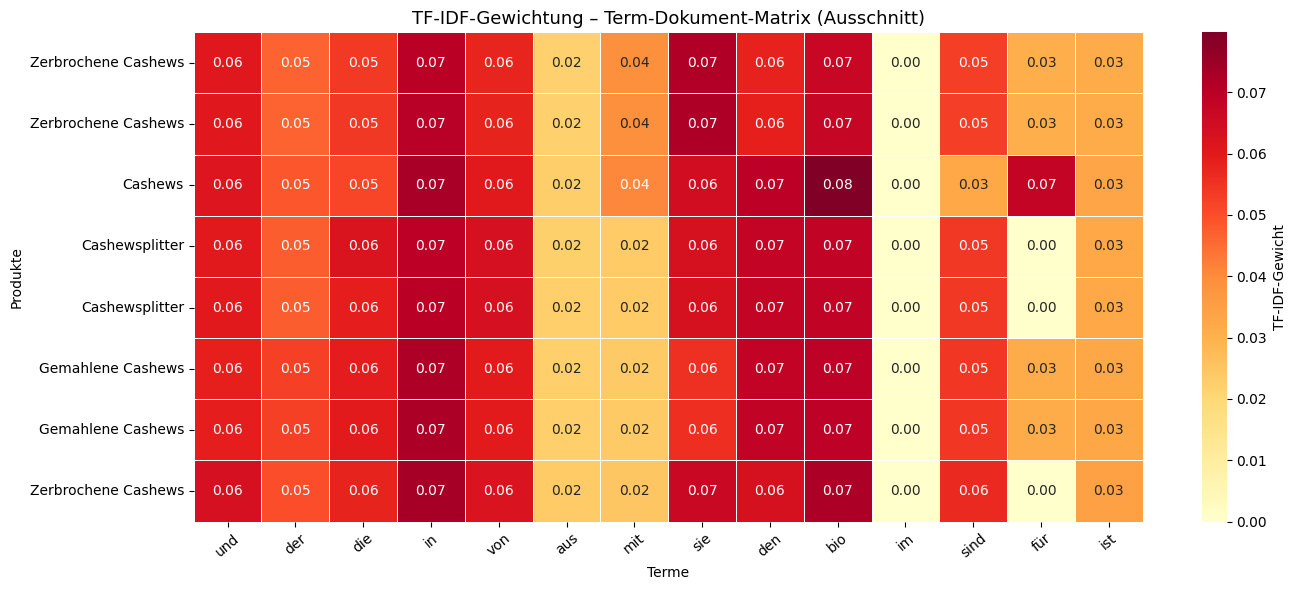

In [15]:
# Produkte mit reichhaltiger Beschreibung wählen
top_idx_prod = df_model['text_clean'].str.len().nlargest(8).index
heatmap_t_idx = np.argsort(mean_tfidf)[::-1][:14]
heatmap_terme = feature_names[heatmap_t_idx]

heatmap_data = tfidf_matrix[top_idx_prod, :][:, heatmap_t_idx].toarray()
heatmap_namen = df_model.loc[top_idx_prod, 'name'].str[:30].tolist()

heatmap_df = pd.DataFrame(heatmap_data, columns=heatmap_terme, index=heatmap_namen)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_df,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'TF-IDF-Gewicht'}
)
ax.set_title('TF-IDF-Gewichtung – Term-Dokument-Matrix (Ausschnitt)', fontsize=13)
ax.set_xlabel('Terme')
ax.set_ylabel('Produkte')
ax.tick_params(axis='x', rotation=40)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Top-Terme eines Produkts

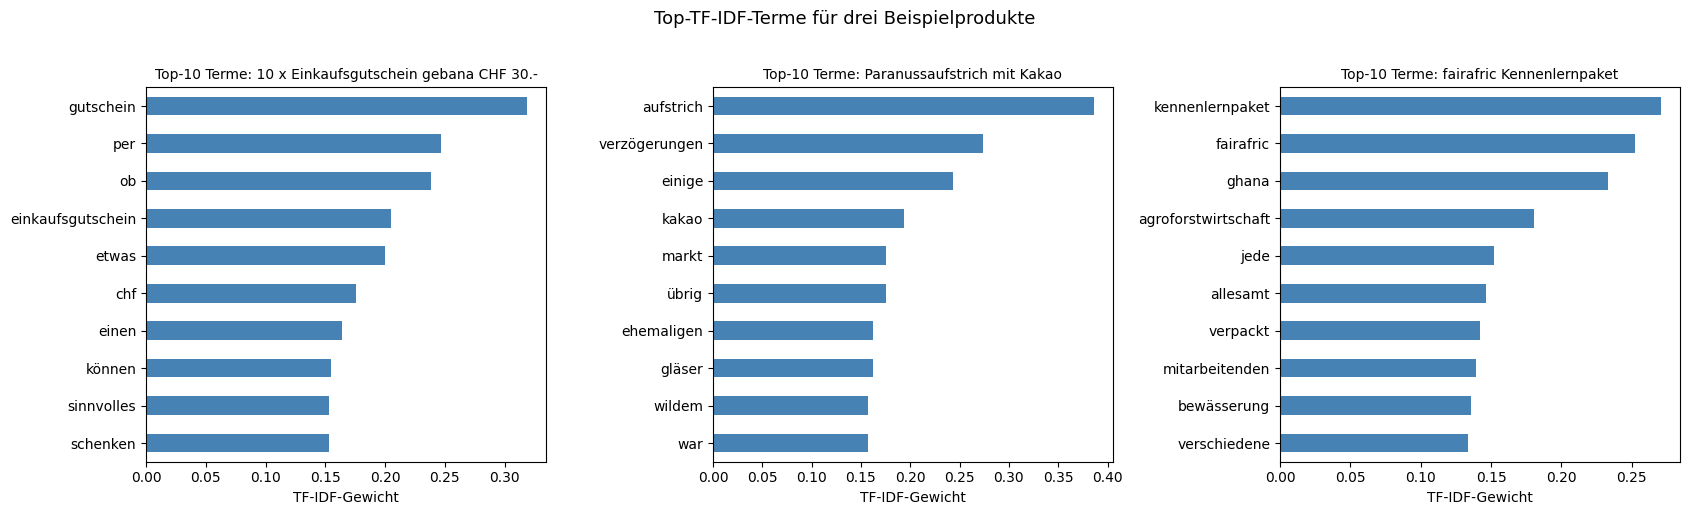

In [16]:
def plot_top_terme(produkt_idx, top_n=12, ax=None):
    name = df_model.loc[produkt_idx, 'name']
    vektor = tfidf_matrix[produkt_idx]
    non_zero = vektor.nonzero()[1]
    scores = pd.Series(
        {feature_names[i]: vektor[0, i] for i in non_zero}
    ).sort_values(ascending=False).head(top_n)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    scores.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top-{top_n} Terme: {name[:40]}', fontsize=10)
    ax.set_xlabel('TF-IDF-Gewicht')
    return ax


kandidaten = df_model[df_model['text_clean'].str.len() > 300].index[:3]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, idx in zip(axes, kandidaten):
    plot_top_terme(idx, top_n=10, ax=ax)

plt.suptitle('Top-TF-IDF-Terme für drei Beispielprodukte', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Sparse-Struktur der TF-IDF-Matrix

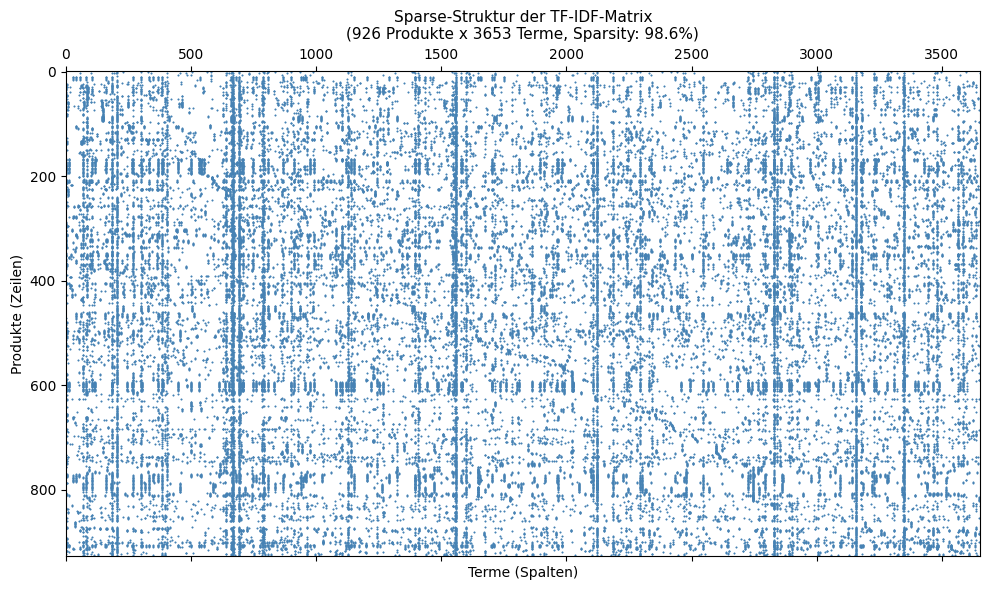

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.spy(tfidf_matrix, markersize=0.5, aspect='auto', color='steelblue')
ax.set_title(
    f'Sparse-Struktur der TF-IDF-Matrix\n'
    f'({tfidf_matrix.shape[0]} Produkte x {tfidf_matrix.shape[1]} Terme, '
    f'Sparsity: {sparsity:.1%})',
    fontsize=11
)
ax.set_xlabel('Terme (Spalten)')
ax.set_ylabel('Produkte (Zeilen)')
plt.tight_layout()
plt.show()

---
## 5. Kosinus-Ähnlichkeit

Die Ähnlichkeit zwischen zwei Produktvektoren wird mit der Kosinus-Ähnlichkeit gemessen:

```
cos(a, b) = (a . b) / (||a|| * ||b||)
```

- Wert 1.0: Vektoren sind identisch
- Wert 0.0: keine gemeinsamen Terme

Da TF-IDF-Vektoren L2-normiert sind, entspricht die Kosinus-Ähnlichkeit dem Skalarprodukt.

In [18]:
cosim_matrix = cosine_similarity(tfidf_matrix)

print(f'Ähnlichkeitsmatrix: {cosim_matrix.shape[0]} x {cosim_matrix.shape[1]}')
print(f'Speicher (ca.): {cosim_matrix.nbytes / 1024**2:.1f} MB')

# Statistik ohne Diagonale
maske = ~np.eye(cosim_matrix.shape[0], dtype=bool)
aehnl_flat = cosim_matrix[maske]

print(f'\nMin:    {aehnl_flat.min():.4f}')
print(f'Max:    {aehnl_flat.max():.4f}')
print(f'Mittel: {aehnl_flat.mean():.4f}')
print(f'Median: {np.median(aehnl_flat):.4f}')

Ähnlichkeitsmatrix: 926 x 926
Speicher (ca.): 6.5 MB

Min:    0.0000
Max:    1.0000
Mittel: 0.0481
Median: 0.0370


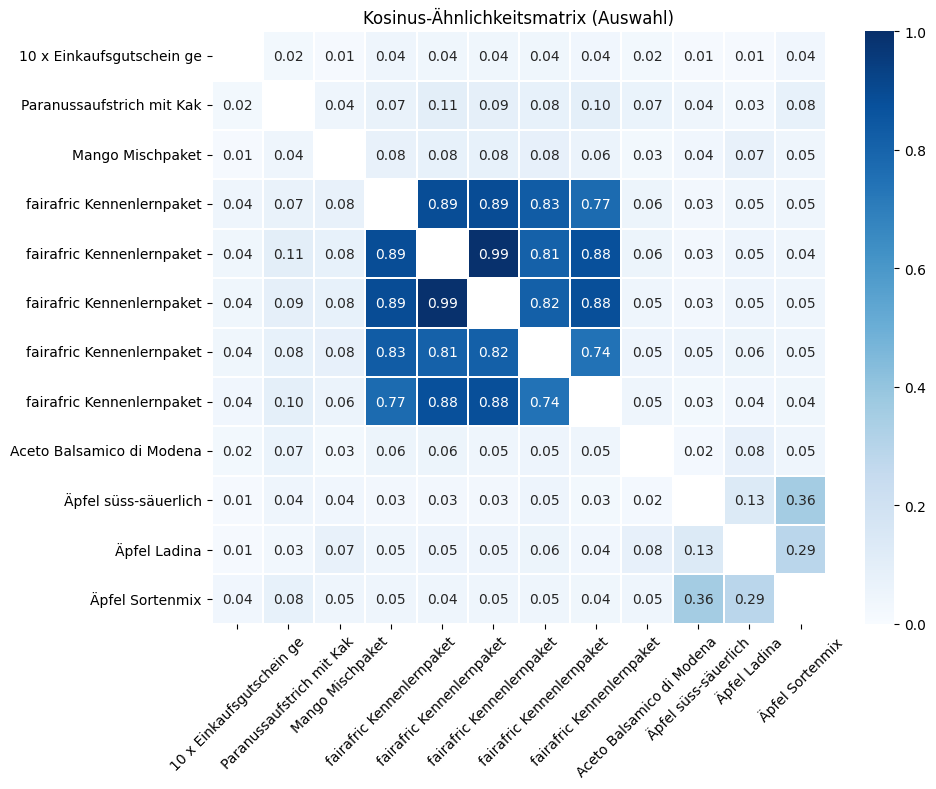

In [19]:
# Ähnlichkeitsmatrix für Produktauswahl visualisieren
N_VIS = 12
vis_idx = df_model[df_model['text_clean'].str.len() > 200].index[:N_VIS]
vis_namen = df_model.loc[vis_idx, 'name'].str[:25].tolist()
vis_cosim = cosim_matrix[np.ix_(vis_idx, vis_idx)]

fig, ax = plt.subplots(figsize=(10, 8))
maske_diag = np.eye(N_VIS, dtype=bool)
sns.heatmap(
    vis_cosim,
    annot=True, fmt='.2f',
    cmap='Blues',
    xticklabels=vis_namen,
    yticklabels=vis_namen,
    ax=ax,
    linewidths=0.2,
    mask=maske_diag,
    vmin=0, vmax=1
)
ax.set_title('Kosinus-Ähnlichkeitsmatrix (Auswahl)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

---
## 6. Empfehlungsfunktion

Die Funktion nimmt ein Produkt entgegen und gibt die TOP_N ähnlichsten Produkte
sortiert nach absteigender Kosinus-Ähnlichkeit zurück.

In [20]:
# Lookup: EXTERNALKEY -> Index
id_zu_idx = pd.Series(df_model.index, index=df_model['artikel_id'].str.strip())


def empfehle(artikel_id, top_n=TOP_N, verbose=True):
    """
    Gibt die top_n ähnlichsten Produkte zur Eingabe-EXTERNALKEY zurück.

    Parameter
    ----------
    artikel_id : str   EXTERNALKEY des Produkts (aus dem PIM-System)
    top_n      : int   Anzahl Empfehlungen
    verbose    : bool  Ausgabe auf Konsole

    Rückgabe
    ---------
    DataFrame mit: artikel_id, name, aehnlichkeit
    """
    artikel_id = str(artikel_id).strip()

    if artikel_id not in id_zu_idx:
        raise ValueError(f'Produkt nicht gefunden – EXTERNALKEY: {artikel_id}')

    idx = id_zu_idx[artikel_id]
    if hasattr(idx, '__len__'):
        idx = int(idx.iloc[0])

    produkt_name = df_model.loc[idx, 'name']
    aehnlichkeiten = cosim_matrix[idx]
    sortiert = np.argsort(aehnlichkeiten)[::-1]
    top_idx = [i for i in sortiert if i != idx][:top_n]

    ergebnis = df_model.loc[top_idx, ['artikel_id', 'name']].copy()
    ergebnis['aehnlichkeit'] = aehnlichkeiten[top_idx].round(4)
    ergebnis = ergebnis.reset_index(drop=True)

    if verbose:
        print(f'\nEingabe: [{artikel_id}] {produkt_name}')
        print(f'Top-{top_n} Empfehlungen:')
        print(ergebnis.to_string(index=False))

    return ergebnis


print('Empfehlungsfunktion bereit.')

Empfehlungsfunktion bereit.


---
## 7. Anwendungsbeispiele

In [21]:
# Beispiel 1: Ananas
# EXTERNALKEY nachschlagen via: df_model[df_model['name'].str.contains('Ananas Cayenne Lisse')][['artikel_id','name']]
_ = empfehle('1020656', top_n=TOP_N)


Eingabe: [1020656] Granatäpfel Ermioni
Top-6 Empfehlungen:
artikel_id                 name  aehnlichkeit
   1009527  Granatäpfel Ermioni        0.9871
   1020655  Granatäpfel Ermioni        0.8097
   1006952  Granatäpfel Ermioni        0.8097
   1022198     Granatäpfel Acco        0.3699
   1021905     Granatäpfel Acco        0.3699
   1022005 Mandarinen Nadorcott        0.3441


In [22]:
# Beispiel 2: Schokolade
# EXTERNALKEY nachschlagen via: df_model[df_model['name'].str.contains('fairafric Kennenlernpaket')][['artikel_id','name']]
_ = empfehle('1021862', top_n=TOP_N)


Eingabe: [1021862] Limetten
Top-6 Empfehlungen:
artikel_id              name  aehnlichkeit
   1022021          Limetten        0.4448
   1021782   Passionsfrüchte        0.3098
   1021783   Passionsfrüchte        0.3098
   1022290 Artischocken Tema        0.2696
   1021904      Kiwi Hayward        0.2433
   1021813            Ananas        0.2372


In [23]:
# Beispiel 3: Kaese
# EXTERNALKEY nachschlagen via: df_model[df_model['name'].str.contains('Bündner Alpkäse')][['artikel_id','name']]
_ = empfehle('1020473', top_n=TOP_N)


Eingabe: [1020473] Kichererbsen
Top-6 Empfehlungen:
artikel_id                                    name  aehnlichkeit
   1020472                           Braune Linsen        0.7896
   1021888                           Braune Linsen        0.7823
   1020474                                Couscous        0.6709
   1021972                                Couscous        0.6645
   1019963               Renata Fonte, Hisotelaray        0.2091
   1019964 Alberelli de la Santa Rosé, Hisotelaray        0.1847


In [24]:
# Alle verfuegbaren Produkte mit Beschreibung anzeigen (EXTERNALKEY + Name)
verfuegbar = df_model[df_model['beschreibung'].notna()][['artikel_id', 'name']].copy()
print(f'Produkte mit Beschreibung: {len(verfuegbar)}')
print('\nErste 20 Produkte:')
print(verfuegbar.head(20).to_string(index=False))

Produkte mit Beschreibung: 858

Erste 20 Produkte:
artikel_id                                    name
   1017400  10 x Einkaufsgutschein gebana CHF 30.-
   1021776             Paranussaufstrich mit Kakao
   1021079                        Mango Mischpaket
   1016764               fairafric Kennenlernpaket
   1020689               fairafric Kennenlernpaket
   1021758               fairafric Kennenlernpaket
   1021419               fairafric Kennenlernpaket
   1022134               fairafric Kennenlernpaket
   1018959        Aceto Balsamico di Modena I.G.P.
   1018973                    Äpfel süss-säuerlich
   1021698                            Äpfel Ladina
   1020576                         Äpfel Sortenmix
   1019329                             Sommeräpfel
   1022011                        Säuerliche Äpfel
   1019964 Alberelli de la Santa Rosé, Hisotelaray
   1018943                         Bündner Alpkäse
   1000969                           Urner Alpkäse
   1022234          Mutschli vo

In [25]:
# Eigene Anfrage: EXTERNALKEY eintragen (z.B. aus der Liste oben)
MEIN_EXTERNALKEY = '1020576'

_ = empfehle(MEIN_EXTERNALKEY, top_n=TOP_N)


Eingabe: [1020576] Äpfel Sortenmix
Top-6 Empfehlungen:
artikel_id                      name  aehnlichkeit
   1018973      Äpfel süss-säuerlich        0.3570
   1021698              Äpfel Ladina        0.2891
   1019329               Sommeräpfel        0.2422
   1022011          Säuerliche Äpfel        0.2343
   1021680      Kefen Hof Rauspfeife        0.2209
   1022008 Joghurt, Milch und Butter        0.1778


### 7.1 Visualisierung der Empfehlungen

In [26]:
def plot_empfehlungen(artikel_id, top_n=6):
    artikel_id = str(artikel_id).strip()
    df_emp = empfehle(artikel_id, top_n=top_n, verbose=False)
    produkt_name = df_model.loc[id_zu_idx[artikel_id], 'name']

    fig, ax = plt.subplots(figsize=(9, 4))
    farben = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_emp))[::-1])
    labels = df_emp['artikel_id'] + '  ' + df_emp['name'].str[:30]
    bars = ax.barh(labels, df_emp['aehnlichkeit'], color=farben)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Kosinus-Ähnlichkeit')
    ax.set_title(f'Empfehlungen für: [{artikel_id}] {produkt_name[:40]}', fontsize=11)
    ax.invert_yaxis()

    for bar, val in zip(bars, df_emp['aehnlichkeit']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()


# EXTERNALKEYs der Beispielprodukte eintragen:
for key in ['EXTERNALKEY_ANANAS', 'EXTERNALKEY_SCHOKOLADE', 'EXTERNALKEY_KAESE']:
    try:
        plot_empfehlungen(key, top_n=5)
    except ValueError as e:
        print(e)

Produkt nicht gefunden – EXTERNALKEY: EXTERNALKEY_ANANAS
Produkt nicht gefunden – EXTERNALKEY: EXTERNALKEY_SCHOKOLADE
Produkt nicht gefunden – EXTERNALKEY: EXTERNALKEY_KAESE


---
## 8. Analyse der Ähnlichkeitsverteilung

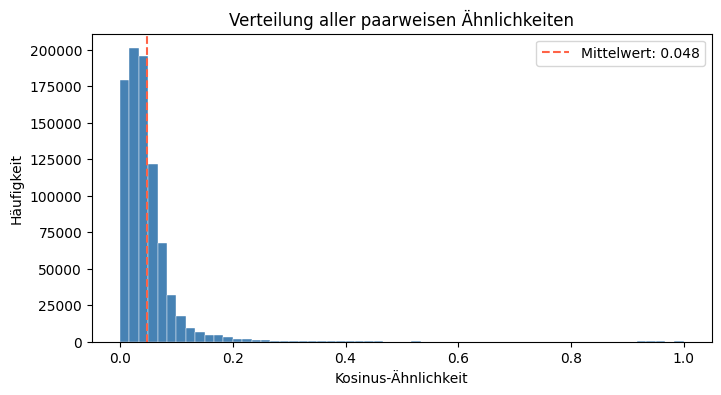

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

# Histogramm
ax.hist(aehnl_flat, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Kosinus-Ähnlichkeit')
ax.set_ylabel('Häufigkeit')
ax.set_title('Verteilung aller paarweisen Ähnlichkeiten')
mittel = np.mean(aehnl_flat)
ax.axvline(mittel, color='tomato', linestyle='--', label=f'Mittelwert: {mittel:.3f}')
ax.legend()


---
## 9. Zusammenfassung

Das Content-Based Filtering System für den gebana-Produktkatalog:

1. **Datenbasis:** Produktattribute werden zu einem kombinierten Textfeld zusammengeführt.
2. **Vorverarbeitung:** Tokenisierung, optionale Stopwort-Entfernung und Stemming.
3. **TF-IDF:** Jedes Produkt wird als Vektor repräsentiert. Begriffe mit hoher Unterscheidungskraft erhalten hohe Gewichte.
4. **Kosinus-Ähnlichkeit:** Misst die inhaltliche Verwandtschaft zwischen Produktvektoren.
5. **Empfehlung:** Die ähnlichsten Produkte werden sortiert zurückgegeben.

**Stärken:**
- Kein Kaltstart-Problem
- Vollständig transparent und nachvollziehbar
- Keine Nutzerverhaltensdaten nötig

**Einschränkungen:**
- Qualität hängt von der Vollständigkeit der Produktbeschreibungen ab
- Semantische Zusammenhänge (Synonyme) werden nicht erkannt
- Sehr ähnliche Artikel (z. B. gleicher Artikel in verschiedenen Größen) erhalten hohe Ähnlichkeitswerte

In [28]:
print('=' * 50)
print('  Modellstatistik – TF-IDF Empfehlungssystem')
print('=' * 50)
print(f'  Produkte im Modell:       {tfidf_matrix.shape[0]}')
print(f'  Terme im Vokabular:       {tfidf_matrix.shape[1]}')
print(f'  Sparsity der Matrix:      {sparsity:.1%}')
print(f'  Stoppwörter aktiv:        {USE_STOPWORDS}')
print(f'  Stemming aktiv:           {USE_STEMMING}')
print(f'  Empfehlungen pro Anfrage: {TOP_N}')
print(f'  Mittlere Ähnlichkeit:    {np.mean(aehnl_flat):.4f}')
print('=' * 50)

  Modellstatistik – TF-IDF Empfehlungssystem
  Produkte im Modell:       926
  Terme im Vokabular:       3653
  Sparsity der Matrix:      98.6%
  Stoppwörter aktiv:        False
  Stemming aktiv:           False
  Empfehlungen pro Anfrage: 6
  Mittlere Ähnlichkeit:    0.0481


---
## 10. Export – Empfehlungen und Vektoren speichern

Die berechneten Empfehlungen werden als CSV exportiert, damit `02-Empfehlungen-auswerten.py`
sie ohne TF-IDF-Neuberechnung laden kann. Optional wird auch die TF-IDF-Matrix
als komprimiertes NPZ-Archiv gespeichert.

In [29]:
import scipy.sparse
from pathlib import Path

EXPORT_DIR = Path('Ergebnisse')
EXPORT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------------
# 10.1 Empfehlungen als CSV exportieren
# Format: produkt_id | empfohlen_id | rang (1-basiert) | score
# ------------------------------------------------------------------
zeilen = []
for idx, row in df_model.iterrows():
    artikel_id = str(row['artikel_id']).strip()
    sim = cosim_matrix[idx]
    sortiert = [i for i in sim.argsort()[::-1] if i != idx][:TOP_N]
    for rang, emp_idx in enumerate(sortiert, start=1):
        zeilen.append({
            'produkt_id':    artikel_id,
            'empfohlen_id':  str(df_model.at[emp_idx, 'artikel_id']).strip(),
            'rang':          rang,
            'score':         round(float(sim[emp_idx]), 6),
        })

df_empfehlungen = pd.DataFrame(zeilen)
empf_pfad = EXPORT_DIR / 'Produktempfehlungen.csv'
df_empfehlungen.to_csv(empf_pfad, index=False, sep=';', encoding='utf-8-sig')
print(f'Empfehlungen exportiert: {empf_pfad}  ({len(df_empfehlungen)} Zeilen)')

# ------------------------------------------------------------------
# 10.2 TF-IDF-Matrix als NPZ speichern (sparse, platzsparend)
# ------------------------------------------------------------------
npz_pfad = EXPORT_DIR / 'Aehnlichkeitsmatrix.npz'
scipy.sparse.save_npz(str(npz_pfad), tfidf_matrix)
print(f'TF-IDF-Matrix gespeichert: {npz_pfad}  {tfidf_matrix.shape}')

# ------------------------------------------------------------------
# 10.3 Produkt-ID-Liste speichern (Zeilenzuordnung zur Matrix)
# ------------------------------------------------------------------
ids_pfad = EXPORT_DIR / 'Produktverzeichnis.csv'
df_model[['artikel_id', 'name']].to_csv(ids_pfad, index=False, sep=';', encoding='utf-8-sig')
print(f'Produkt-IDs gespeichert:  {ids_pfad}  ({len(df_model)} Produkte)')

print('\nExport abgeschlossen. 02-Empfehlungen-auswerten.py kann jetzt ausgefuehrt werden.')
df_empfehlungen.head(8)

Empfehlungen exportiert: Ergebnisse\Produktempfehlungen.csv  (5556 Zeilen)
TF-IDF-Matrix gespeichert: Ergebnisse\Aehnlichkeitsmatrix.npz  (926, 3653)
Produkt-IDs gespeichert:  Ergebnisse\Produktverzeichnis.csv  (926 Produkte)

Export abgeschlossen. 02-Empfehlungen-auswerten.py kann jetzt ausgefuehrt werden.


,produkt_id,empfohlen_id,rang,score
0,1017400,1017399,1,1.000000
1,1017400,1000559,2,0.959019
2,1017400,1000287,3,0.959019
3,1017400,1000666,4,0.959019
4,1017400,1000219,5,0.959019
5,1017400,1000110,6,0.959019
6,1021033,1021032,1,1.000000
7,1021033,1021030,2,1.000000
